# Playbook: SAM 3 (detekcja) na zdjęciu satelitarnym z Fort Myers Beach

Zestaw ćwiczeń do **notebooka 06** (`06_detekcja_obiektow_sam3.ipynb`). Tam SAM 3 liczył zbiorniki paliwa, baseny i budynki
na zdjęciu satelitarnym Tampy. Tutaj robisz to samo na **innej scenie, z innymi obiektami**: `dane/fort_myers_satelita.tif` —
San Carlos Island / Fort Myers Beach (Floryda), kemping z przyczepami kempingowymi, marina, pole kotwiczenia łodzi na
otwartej wodzie i osiedle kanałowe z prywatnymi pomostami. Zdjęcie pochodzi z tego samego programu Maxar Open Data
(zdarzenie „Hurricane Ian”), 2022-01-21, piksel 0,5 m, EPSG:32617. **Kąt od pionu jest tu dużo większy niż w Tampie
(ok. 44° zamiast 4,6°)** — wysokie obiekty są wyraźniej „pochylone”, warto na to zwracać uwagę na rysunkach.

**To playbook, nie ćwiczenie z programowania.** Cały kod jest już w notebooku i pochodzi z notebooka 06. Ty:

1. uruchamiasz komórki po kolei od góry: `Shift + Enter`,
2. w komórkach **TWOJA KOLEJ** zmieniasz tylko to, co stoi między liniami `ZMIEŃ TU`: nazwy w cudzysłowie, litery kadrów,
   liczby (ułamki z **kropką**: `0.5`, nie `0,5`). Cudzysłowy, przecinki i nawiasy zostają,
3. zastanawiasz się nad pytaniami pod zadaniem — odpowiedzi prowadzącego są w osobnym pliku `_rozwiazania`.

Komórki oznaczone **GOTOWE** tylko uruchamiasz. Nie musisz ich czytać.

**Czego tu nie ma:** poprawek w QGIS (jak w zadaniach do poziomu 4) — ramki nie mają masek do poprawiania kształtu, tylko
usuwa się/dodaje wiersze w tabeli atrybutów, co każdy robi inaczej — oraz douczania modelu (detekcja nie daje masek
pikselowych, których potrzebuje U-Net z poziomu 3).

Notebook używa **pełnego `facebook/sam3`** (tak jak notebook 06), nie odchudzonego SAM3-LiteText z poziomu 4 — na tym
komputerze dostęp jest już przyznany. Wyniki, które zapiszesz, trafiają do `wyniki/zadania_detekcja/`.

## Playbook w 5 krokach

| Krok | Pytanie | Zadanie | Notebook 06, sekcja |
|---|---|---|---|
| 1. Nazwa: kemping | Czy model w ogóle zna tę nazwę? Czy inna fraza nie „podkrada” mu obiektów? | 1 | 3 |
| 2. Nazwa: łodzie | Która fraza najlepiej opisuje łodzie na wodzie? | 2 | 3.1–3.2 |
| 3. Próg | Ile wątpliwych obiektów odsiać, żeby nie stracić prawdziwych? | 3 | 3.3 |
| 4. Całe zdjęcie | Jaki kafel i jakie frazy do zliczenia obiektów z całej sceny? | 4 | 4–5 |
| 5. Ocena względem OSM | Które klasy da się w ogóle sprawdzić względem OSM? | 5 | 6 |

## Gdy coś nie działa

| Objaw | Co zrobić |
|---|---|
| Komunikat ⚠️ pod komórką | Przeczytaj go: mówi, co poprawić (np. przecinek zamiast kropki, brakujący cudzysłów) |
| `NameError: name '...' is not defined` | Pominąłeś komórkę wyżej. Uruchom notebook od góry (*Run All*) |
| Komórka liczy się długo (gwiazdka `[*]`) | Zadanie 4 na całym zdjęciu trwa kilka minut na GPU, dłużej na samym CPU |
| Zmieniłem wartość, a wynik ten sam | Uruchom ponownie **tę** komórkę (`Shift + Enter`) |
| Błąd przy pobieraniu modelu | Sprawdź połączenie z internetem i uruchom komórkę jeszcze raz |
| Zadanie 5 mówi „nie ma jeszcze pliku” | Uruchom najpierw zadanie 4 z frazą `"building"` w `FRAZY_I_KLASY` |


## Część 0. GOTOWE: uruchom po kolei, bez zmian

In [4]:
from huggingface_hub import login
import getpass

login(token=getpass.getpass("Token Hugging Face: "))

In [ ]:
# GOTOWE: uruchom bez zmian (Shift + Enter)
import time
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import torch
from huggingface_hub.errors import GatedRepoError
from IPython.display import display
from matplotlib.patches import Patch, Rectangle
from shapely.geometry import box as skrzynka

plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 11})

SCIEZKA_ZDJECIA = Path("data/fort_myers_satelita.tif")
SCIEZKA_OSM = Path("data/fort_myers_osm.gpkg")
KATALOG_WYNIKOW = Path("wyniki/zadania_detekcja")
KATALOG_WYNIKOW.mkdir(parents=True, exist_ok=True)
if not SCIEZKA_ZDJECIA.exists():
    raise FileNotFoundError("Brak pliku dane/fort_myers_satelita.tif. Uruchom w terminalu:  python pobierz_fort_myers.py")

# Pełny SAM 3 (jak w notebooku 06) — wymaga zgody Meta na Hugging Face (na tym komputerze już przyznanej)
ID_MODELU = "facebook/sam3"
URZADZENIE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

print(f"Wczytuję model na urządzeniu „{URZADZENIE}” (ok. 10 s; za pierwszym razem dłużej — wagi ok. 3,4 GB)...")
t0 = time.perf_counter()
try:
    from transformers import Sam3Model, Sam3Processor        # NIE AutoModel: ten checkpoint ma też wariant do wideo
    procesor = Sam3Processor.from_pretrained(ID_MODELU)
    model = Sam3Model.from_pretrained(ID_MODELU).to(URZADZENIE).eval()
except GatedRepoError as blad:
    raise RuntimeError(f"Brak dostępu do {ID_MODELU} (wagi „gated”). Poproś prowadzącego o dostęp.") from blad
print(f"✅ Model gotowy ({time.perf_counter() - t0:.0f} s).")

Wczytuję model na urządzeniu „mps” (ok. 10 s; za pierwszym razem dłużej — wagi ok. 3,4 GB)...


/Users/marcin/geoai_ml/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `memory_attention_rope_theta` is deprecated and will be removed in v5.0. Use `rope_parameters['rope_theta']` instead.
Loading weights: 100%|██████████| 1468/1468 [00:00<00:00, 7765.39it/s]


✅ Model gotowy (9 s).


In [5]:
# GOTOWE: uruchom bez zmian (Shift + Enter)
# ===== Funkcje z notebooka 06 (skopiowane bez zmian) =====
PROG = 0.5    # minimalna pewność obiektu
KLASY_DO_WYBORU = ["przyczepa", "łódź", "budynek"]
POJECIE_NA_WARSTWE_OSM = {"building": "budynki"}    # jedyna fraza z sensowną referencją w OSM na tej scenie


def wczytaj_zdjecie(sciezka):
    """Zwraca: rgb (H,W,3 uint8), waznie (H,W bool), profil (transform, crs), gsd [m/piksel]."""
    with rasterio.open(sciezka) as src:
        if src.count < 3 or src.dtypes[0] != "uint8":
            raise ValueError(f"Oczekuję 8-bitowego RGB, a jest: {src.count} pasm, {src.dtypes[0]}")
        rgb = np.moveaxis(src.read([1, 2, 3]), 0, -1)
        profil = {"transform": src.transform, "crs": src.crs}
        gsd = src.res[0]
    waznie = ~(rgb == 0).all(axis=-1)
    return rgb, waznie, profil, gsd


def koduj_obraz(obraz):
    """Ciężki krok: RGB uint8 (H,W,3) → cechy obrazu (do wielokrotnego użycia) i rozmiar oryginału [[H, W]]."""
    wejscie = procesor(images=obraz, return_tensors="pt")
    with torch.no_grad():
        cechy = model.get_vision_features(pixel_values=wejscie["pixel_values"].to(URZADZENIE))
    return cechy, wejscie["original_sizes"].tolist()


def znajdz_obiekty(cechy, rozmiar, pojecie, prog=PROG, wiersz0=0, kolumna0=0):
    """Lekki krok: fraza -> obiekty jako ramki w układzie CAŁEGO zdjęcia (przesunięte o wiersz0, kolumna0)."""
    wejscie = procesor(text=pojecie, return_tensors="pt")
    with torch.no_grad():
        wyjscie = model(vision_embeds=cechy, input_ids=wejscie["input_ids"].to(URZADZENIE),
                        attention_mask=wejscie["attention_mask"].to(URZADZENIE))
    wynik = procesor.post_process_object_detection(wyjscie, threshold=prog, target_sizes=rozmiar)[0]
    return [{"ramka": (kolumna0 + x1, wiersz0 + y1, kolumna0 + x2, wiersz0 + y2), "wynik": float(s), "pojecie": pojecie}
            for (x1, y1, x2, y2), s in zip(wynik["boxes"].tolist(), wynik["scores"].tolist())]


def rysuj_ramki(ax, obraz, obiekty, kolor="lime", offset=(0, 0)):
    """Rysuje ramki obiektów na obrazie (offset = (wiersz0, kolumna0) obrazu w układzie ramek)."""
    ax.imshow(obraz)
    w0, k0 = offset
    for o in obiekty:
        x1, y1, x2, y2 = o["ramka"]
        ax.add_patch(Rectangle((x1 - k0, y1 - w0), x2 - x1, y2 - y1, fill=False, ec=kolor, lw=1.6))
    ax.axis("off")


def pokaz_pojecia(obraz, wyniki, tytul_obrazu="Kadr", kolor="lime"):
    """Kadr i po jednym panelu na frazę: ramki + liczba obiektów."""
    fig, ax = plt.subplots(1, len(wyniki) + 1, figsize=(4.6 * (len(wyniki) + 1), 4.8))
    ax[0].imshow(obraz); ax[0].set_title(tytul_obrazu); ax[0].axis("off")
    for a, (fraza, obiekty) in zip(ax[1:], wyniki.items()):
        rysuj_ramki(a, obraz, obiekty, kolor=kolor)
        a.set_title(f"„{fraza}”: {len(obiekty)} obiekt.")
    plt.tight_layout()


def poczatki_kafli(n, kafel, zakladka):
    """Początki kafli o boku `kafel` px, równomiernie pokrywających `n` px, z zakładką nie mniejszą niż `zakladka`."""
    if n <= kafel:
        return [0]
    liczba = int(np.ceil((n - zakladka) / (kafel - zakladka)))
    return np.linspace(0, n - kafel, liczba).round().astype(int).tolist()


def iou_ramek(a, b):
    """IoU dwóch ramek (x1, y1, x2, y2)."""
    x1, y1, x2, y2 = a; X1, Y1, X2, Y2 = b
    xi1, yi1, xi2, yi2 = max(x1, X1), max(y1, Y1), min(x2, X2), min(y2, Y2)
    if xi2 <= xi1 or yi2 <= yi1:
        return 0.0
    przeciecie = (xi2 - xi1) * (yi2 - yi1)
    suma = (x2 - x1) * (y2 - y1) + (X2 - X1) * (Y2 - Y1) - przeciecie
    return przeciecie / suma if suma > 0 else 0.0


def detekcje_kafelkami(rgb, waznie, pojecia, gsd, kafel_m, zakladka_m, prog=PROG, iou_dedup=0.5):
    """SAM 3 na kafelkach z zakładką, dla każdej frazy. Zwraca ({fraza: obiekty}, liczba policzonych kafli)."""
    wys_zdj, szer_zdj = waznie.shape
    kafel, zakladka = round(kafel_m / gsd), round(zakladka_m / gsd)
    kandydaci = {p: [] for p in pojecia}
    n_kafli = 0
    for w0 in poczatki_kafli(wys_zdj, kafel, zakladka):
        for k0 in poczatki_kafli(szer_zdj, kafel, zakladka):
            okno = np.s_[w0:w0 + kafel, k0:k0 + kafel]
            wys_k, szer_k = waznie[okno].shape
            if waznie[okno].mean() < 0.05:
                continue
            n_kafli += 1
            cechy, rozmiar = koduj_obraz(rgb[okno].copy())
            for p in pojecia:
                for o in znajdz_obiekty(cechy, rozmiar, p, prog, w0, k0):
                    x1, y1, x2, y2 = o["ramka"]
                    x1, y1, x2, y2 = x1 - k0, y1 - w0, x2 - k0, y2 - w0     # w układzie kafla
                    ucieta = ((x1 <= 0.5 and k0 > 0) or (y1 <= 0.5 and w0 > 0)
                              or (x2 >= szer_k - 0.5 and k0 + szer_k < szer_zdj)
                              or (y2 >= wys_k - 0.5 and w0 + wys_k < wys_zdj))
                    if not ucieta:
                        kandydaci[p].append(o)
    wynik = {}
    for p, lista in kandydaci.items():
        lista.sort(key=lambda o: -o["wynik"])
        zostawione = []
        for o in lista:
            if all(iou_ramek(o["ramka"], z["ramka"]) < iou_dedup for z in zostawione):
                zostawione.append(o)
        wynik[p] = zostawione
    return wynik, n_kafli


def ramki_do_gdf(obiekty_wg_frazy, profil, gsd, pojecie_na_klasa):
    """{fraza: obiekty} -> GeoDataFrame: prostokąt w układzie mapy + fraza, klasa, pewność, powierzchnia."""
    wiersze = []
    for fraza, lista in obiekty_wg_frazy.items():
        for o in lista:
            x1, y1, x2, y2 = o["ramka"]
            (mx1, my1) = profil["transform"] * (x1, y2)
            (mx2, my2) = profil["transform"] * (x2, y1)
            wiersze.append({"id": len(wiersze) + 1, "pojecie": fraza, "klasa": pojecie_na_klasa[fraza],
                            "wynik": round(o["wynik"], 2), "pow_m2": round((x2 - x1) * (y2 - y1) * gsd ** 2, 1),
                            "geometry": skrzynka(mx1, my1, mx2, my2)})
    return gpd.GeoDataFrame(pd.DataFrame(wiersze, columns=["id", "pojecie", "klasa", "wynik", "pow_m2", "geometry"]),
                            geometry="geometry", crs=profil["crs"])


def ocena_wzgledem_osm(gdf_det, sciezka_osm, pojecie, warstwa):
    """Dopasowanie po przecięciu geometrii. Zwraca (liczba OSM, dopasowane OSM, liczba detekcji, detekcje bez OSM)."""
    gdf_osm = gpd.read_file(sciezka_osm, layer=warstwa)
    gdf_osm = gdf_osm[gdf_osm.is_valid & ~gdf_osm.is_empty].reset_index(drop=True)
    gdf_d = gdf_det[gdf_det["pojecie"] == pojecie].reset_index(drop=True)

    osm_dopasowane = gpd.sjoin(gdf_osm, gdf_d, predicate="intersects", how="left")["index_right"].notna()
    osm_dopasowane = osm_dopasowane.groupby(level=0).any()
    det_dopasowane = gpd.sjoin(gdf_d, gdf_osm, predicate="intersects", how="left")["index_right"].notna()
    det_dopasowane = det_dopasowane.groupby(level=0).any()

    return {"OSM (referencja)": len(gdf_osm), "OSM dopasowanych": int(osm_dopasowane.sum()),
            "przybliżona czułość": round(osm_dopasowane.mean(), 3) if len(gdf_osm) else np.nan,
            "detekcji SAM 3": len(gdf_d), "detekcji bez OSM": int((~det_dopasowane).sum())}


# ===== Opakowania na potrzeby zadań: sprawdzają to, co wpisałeś, i rysują wynik =====
import functools


class BladUzytkownika(ValueError):
    """Błąd w ustawieniach wpisanych przez uczestnika: pokazujemy zrozumiały komunikat zamiast długiego raportu błędu."""


def przyjazne(funkcja):
    @functools.wraps(funkcja)
    def opakowana(*argumenty, **nazwane):
        try:
            return funkcja(*argumenty, **nazwane)
        except BladUzytkownika as blad:
            print(f"⚠️  {blad}")
    return opakowana


def sprawdz_kadr(kadr):
    kadr = str(kadr).strip().upper()
    if kadr not in KADRY:
        raise BladUzytkownika(f"Nie ma kadru „{kadr}”. Wpisz jedną z liter: {', '.join(KADRY)} (w cudzysłowie, np. \"A\").")
    return kadr


def sprawdz_fraze(fraza):
    fraza = str(fraza).strip().lower()
    if not fraza:
        raise BladUzytkownika("Fraza jest pusta. Wpisz krótką nazwę po angielsku, np. \"boat\" albo \"car\".")
    if not fraza.isascii():
        raise BladUzytkownika(f"Fraza „{fraza}” ma polskie litery. Model rozumie krótkie frazy po angielsku, np. \"boat\", \"trailer\".")
    if len(fraza.split()) > 4:
        raise BladUzytkownika(f"Fraza „{fraza}” jest za długa. Użyj jednego do trzech słów.")
    return fraza


def sprawdz_prog(prog, nazwa="PROG"):
    try:
        prog = float(prog)
    except (TypeError, ValueError):
        raise BladUzytkownika(f"{nazwa} musi być liczbą od 0.05 do 0.95, np. 0.5 (z KROPKĄ, nie z przecinkiem).") from None
    if not 0.05 <= prog <= 0.95:
        raise BladUzytkownika(f"{nazwa} = {prog} jest poza zakresem. Wpisz liczbę od 0.05 do 0.95.")
    return round(prog, 2)


def pobierz_kadr(kadr):
    w0, k0, _ = KADRY[kadr]
    return np.ascontiguousarray(rgb[w0:w0 + ROZMIAR_KADRU, k0:k0 + ROZMIAR_KADRU])


_CECHY_KADROW = {}


def cechy_kadru(kadr):
    """Koder obrazu (ciężki krok) liczy się raz na kadr; kolejne frazy na tym samym kadrze są szybkie."""
    if kadr not in _CECHY_KADROW:
        _CECHY_KADROW[kadr] = koduj_obraz(pobierz_kadr(kadr))
    return _CECHY_KADROW[kadr]


def opis_kadru(kadr):
    return f"Kadr {kadr}: {KADRY[kadr][2]}"


DZIENNIK_FRAZ = []


@przyjazne
def zadanie_frazy(kadr, frazy, prog=PROG):
    """Zadania 1-2: kilka fraz naraz na kadrze -> ramki obok siebie + tabela liczby obiektów i pewności."""
    kadr, prog = sprawdz_kadr(kadr), sprawdz_prog(prog)
    if isinstance(frazy, str) or not len(frazy):
        raise BladUzytkownika("FRAZY to lista w nawiasach kwadratowych, np. [\"boat\", \"ship\"]. Frazy oddziel przecinkami.")
    frazy = [sprawdz_fraze(f) for f in frazy]
    obraz = pobierz_kadr(kadr)
    cechy, rozmiar = cechy_kadru(kadr)
    wyniki = {f: znajdz_obiekty(cechy, rozmiar, f, prog) for f in frazy}
    pokaz_pojecia(obraz, wyniki, opis_kadru(kadr))
    plt.show()
    tabela = pd.DataFrame({f: {"obiektów": len(o), "najwyższa pewność": round(max((x["wynik"] for x in o), default=0), 2)}
                           for f, o in wyniki.items()}).T
    display(tabela)
    for f, o in wyniki.items():
        DZIENNIK_FRAZ.append({"kadr": kadr, "fraza": f, "próg": prog, "obiektów": len(o),
                              "najwyższa pewność": round(max((x["wynik"] for x in o), default=0), 2)})
    print("Dziennik Twoich prób (ostatnie 10):")
    display(pd.DataFrame(DZIENNIK_FRAZ).tail(10))


@przyjazne
def zadanie_prog(kadr, fraza, progi):
    """Zadanie 3: ta sama fraza przy różnych progach pewności (model liczy się raz, resztę robi odsiew)."""
    kadr, fraza = sprawdz_kadr(kadr), sprawdz_fraze(fraza)
    if isinstance(progi, (int, float, str)) or len(progi) != 3:
        raise BladUzytkownika("PROGI to trzy liczby w nawiasie okrągłym, np. (0.2, 0.4, 0.6).")
    progi = [sprawdz_prog(p, "PROGI") for p in progi]
    obraz = pobierz_kadr(kadr)
    cechy, rozmiar = cechy_kadru(kadr)
    luzne = znajdz_obiekty(cechy, rozmiar, fraza, prog=0.05)
    liczba = lambda p: sum(o["wynik"] >= p for o in luzne)
    skala = np.round(np.arange(0.1, 0.96, 0.05), 2)
    fig, ax = plt.subplots(1, 4, figsize=(17, 4.4), gridspec_kw={"width_ratios": [1.3, 1, 1, 1]})
    ax[0].plot(skala, [liczba(p) for p in skala], "o-", ms=3)
    ax[0].set_xlabel("próg pewności"); ax[0].set_ylabel("liczba obiektów")
    for p in progi:
        ax[0].axvline(p, color="C3", ls=":", lw=1)
    ax[0].set_title(f"{opis_kadru(kadr)}, „{fraza}”: ile obiektów zostaje", fontsize=9)
    for a, p in zip(ax[1:], progi):
        zostaje = [o for o in luzne if o["wynik"] >= p]
        rysuj_ramki(a, obraz, zostaje, kolor="orange")
        a.set_title(f"próg {p}: {len(zostaje)} obiekt.")
    plt.tight_layout(); plt.show()
    wybrane = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    display(pd.DataFrame({"obiektów": [liczba(p) for p in wybrane]}, index=wybrane).rename_axis("próg").T)


DZIENNIK_KAFLI = []


@przyjazne
def zadanie_cala(frazy_i_klasy, kafel_m, prog=PROG):
    """Zadanie 4: całe zdjęcie na kafelkach -> ramki wszystkich klas + GPKG do QGIS."""
    if not isinstance(frazy_i_klasy, dict) or not frazy_i_klasy:
        raise BladUzytkownika("FRAZY_I_KLASY to słownik w klamrach: {\"fraza\": \"klasa\", ...}, np. {\"boat\": \"łódź\"}.")
    frazy_i_klasy = {sprawdz_fraze(f): k for f, k in frazy_i_klasy.items()}
    for f, k in frazy_i_klasy.items():
        if k not in KLASY_DO_WYBORU:
            raise BladUzytkownika(f"Klasa „{k}” (przy frazie „{f}”) nie istnieje. Do wyboru: {', '.join(KLASY_DO_WYBORU)}.")
    try:
        kafel_m = float(kafel_m)
    except (TypeError, ValueError):
        kafel_m = 0
    if not 50 <= kafel_m <= 500:
        raise BladUzytkownika("KAFEL_M to liczba metrów od 50 do 500, np. 200 albo 350.")
    prog = sprawdz_prog(prog)

    t0 = time.perf_counter()
    obiekty, n_kafli = detekcje_kafelkami(rgb, waznie, list(frazy_i_klasy), gsd, kafel_m, kafel_m / 5, prog=prog)
    czas = time.perf_counter() - t0

    gdf = ramki_do_gdf(obiekty, profil, gsd, frazy_i_klasy)
    sciezka_gpkg = KATALOG_WYNIKOW / "fort_myers_detekcje.gpkg"
    try:
        sciezka_gpkg.unlink(missing_ok=True)
        if len(gdf):
            gdf.to_file(sciezka_gpkg, layer="detekcje", driver="GPKG")
        plt.imsave(KATALOG_WYNIKOW / "fort_myers_podglad.png", rgb)
    except PermissionError:
        raise BladUzytkownika(f"Nie mogę zapisać plików w {KATALOG_WYNIKOW}. Zamknij je w QGIS i uruchom komórkę jeszcze raz.") from None

    kolory = dict(zip(frazy_i_klasy, ["orange", "deepskyblue", "lime", "magenta"]))
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(rgb)
    for fraza, lista in obiekty.items():
        for o in lista:
            x1, y1, x2, y2 = o["ramka"]
            ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=kolory[fraza], lw=0.6))
    if len(gdf):
        ax.legend(handles=[Patch(edgecolor=kolory[f], facecolor="none", label=f"{f} ({frazy_i_klasy[f]})") for f in frazy_i_klasy],
                  loc="lower left", fontsize=8)
    ax.axis("off"); ax.set_title(f"Detekcje na całym zdjęciu, kafel {kafel_m:g} m")
    plt.tight_layout(); plt.show()

    print(f"Kafli: {n_kafli}, czas: {czas:.0f} s ({czas / n_kafli:.2f} s/kafel).")
    if not len(gdf):
        print("Nic nie znaleziono: nie zapisano GPKG. Zmień frazy albo kafel.")
    else:
        print(f"Zapisano {sciezka_gpkg.name} ({len(gdf)} obiektów) w {KATALOG_WYNIKOW}/")
    wiersze = []
    for fraza, klasa in frazy_i_klasy.items():
        lista = obiekty[fraza]
        wiersze.append({"fraza": fraza, "klasa": klasa, "obiektów": len(lista),
                        "mediana pewności": round(float(np.median([o["wynik"] for o in lista])), 2) if lista else None})
    display(pd.DataFrame(wiersze).set_index("fraza"))
    DZIENNIK_KAFLI.append({"kafel [m]": kafel_m, "frazy": ", ".join(frazy_i_klasy), "obiektów razem": len(gdf),
                           "czas [s]": round(czas)})
    print("Dziennik Twoich przebiegów:")
    display(pd.DataFrame(DZIENNIK_KAFLI).tail(6))


@przyjazne
def zadanie_ocena_osm(fraza):
    """Zadanie 5: przybliżona ocena zapisanych detekcji względem warstwy OSM (tylko tam, gdzie ma to sens)."""
    fraza = sprawdz_fraze(fraza)
    if fraza not in POJECIE_NA_WARSTWE_OSM:
        raise BladUzytkownika(
            f"Dla frazy „{fraza}” nie ma w OSM sensownej warstwy odniesienia (pojedyncze łodzie i przyczepy kempingowe "
            f"nie są tam mapowane). Sprawdzoną warstwę ma tylko: {', '.join(POJECIE_NA_WARSTWE_OSM)}."
        )
    sciezka_gpkg = KATALOG_WYNIKOW / "fort_myers_detekcje.gpkg"
    if not sciezka_gpkg.exists():
        raise BladUzytkownika("Nie ma jeszcze pliku z zadania 4. Uruchom najpierw zadanie 4 z frazą \"building\" w FRAZY_I_KLASY.")
    gdf = gpd.read_file(sciezka_gpkg, layer="detekcje")
    if fraza not in gdf["pojecie"].values:
        raise BladUzytkownika(f"W zapisanym pliku nie ma detekcji dla frazy „{fraza}”. Uruchom zadanie 4 z tą frazą w FRAZY_I_KLASY.")
    warstwa = POJECIE_NA_WARSTWE_OSM[fraza]
    wynik = ocena_wzgledem_osm(gdf, SCIEZKA_OSM, fraza, warstwa)
    display(pd.Series(wynik).to_frame("wartość"))
    print(f"Przybliżona czułość: {wynik['przybliżona czułość']:.1%} "
          f"({wynik['OSM dopasowanych']} z {wynik['OSM (referencja)']} obiektów OSM „{warstwa}” ma pasującą detekcję).")
    print(f"Detekcji bez odpowiednika w OSM: {wynik['detekcji bez OSM']} z {wynik['detekcji SAM 3']} — to NIE są "
          "automatycznie fałszywe alarmy (OSM może po prostu nie mapować tego miejsca).")
    return wynik

Zdjęcie: 4400 × 4400 px, 2200 × 2200 m, piksel 0.5 m, układ EPSG:32617, ważnych pikseli: 100%.


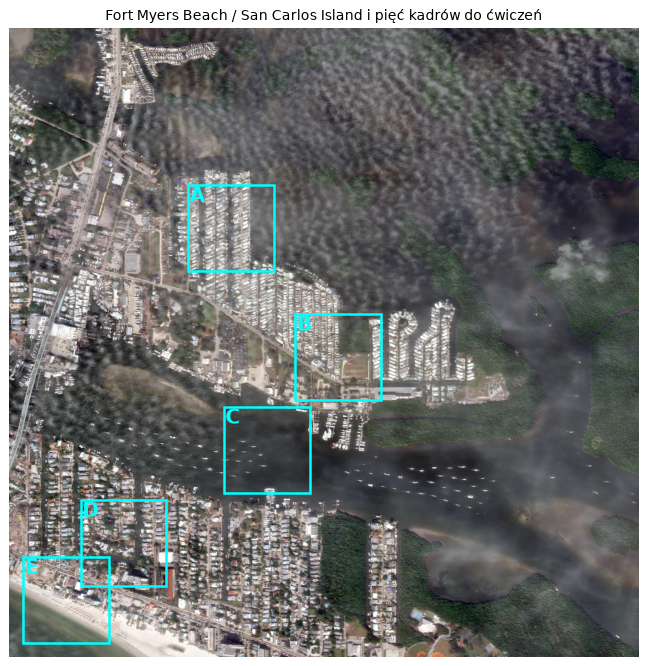

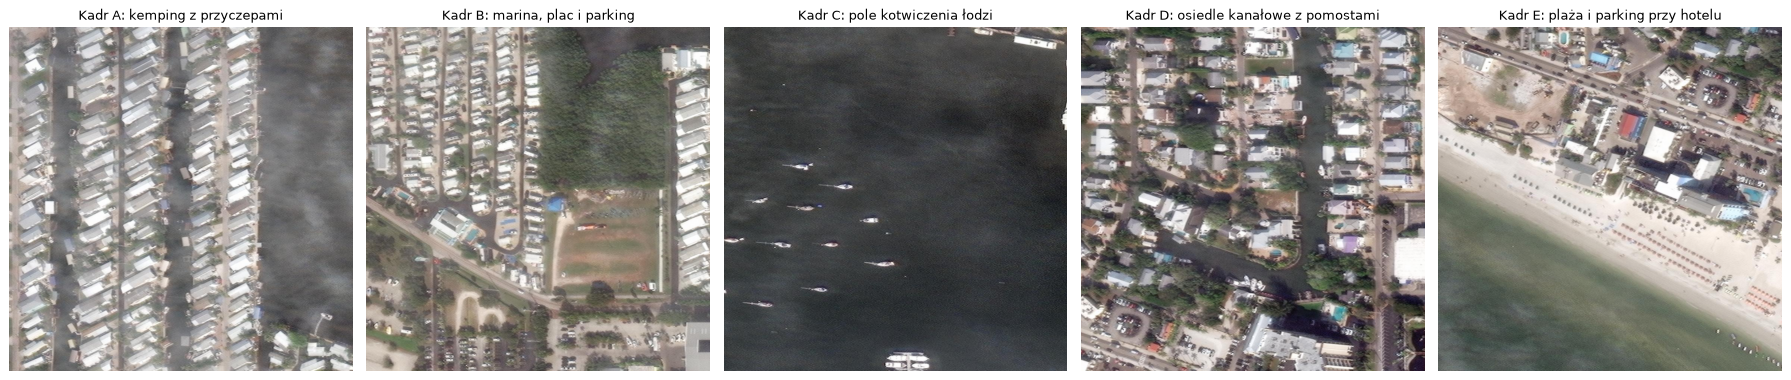

In [6]:
# GOTOWE: uruchom bez zmian (Shift + Enter)
rgb, waznie, profil, gsd = wczytaj_zdjecie(SCIEZKA_ZDJECIA)

# Pięć kadrów do ćwiczeń: (wiersz, kolumna lewego górnego rogu, opis). Każdy ma 600 x 600 px (300 x 300 m).
ROZMIAR_KADRU = 600
KADRY = {
    "A": (1100, 1250, "kemping z przyczepami"),
    "B": (2000, 2000, "marina, plac i parking"),
    "C": (2650, 1500, "pole kotwiczenia łodzi"),
    "D": (3300, 500, "osiedle kanałowe z pomostami"),
    "E": (3700, 100, "plaża i parking przy hotelu"),
}
for nazwa, (w0, k0, _) in KADRY.items():
    assert w0 + ROZMIAR_KADRU <= rgb.shape[0] and k0 + ROZMIAR_KADRU <= rgb.shape[1], f"Kadr {nazwa} wychodzi poza zdjęcie"

print(f"Zdjęcie: {rgb.shape[1]} × {rgb.shape[0]} px, {rgb.shape[1] * gsd:.0f} × {rgb.shape[0] * gsd:.0f} m, piksel {gsd} m, "
      f"układ {profil['crs']}, ważnych pikseli: {waznie.mean():.0%}.")

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(rgb)
for nazwa, (w0, k0, _) in KADRY.items():
    ax.add_patch(Rectangle((k0, w0), ROZMIAR_KADRU, ROZMIAR_KADRU, fill=False, ec="cyan", lw=2))
    ax.text(k0 + 12, w0 + 12, nazwa, color="cyan", fontsize=16, fontweight="bold", va="top")
ax.set_title("Fort Myers Beach / San Carlos Island i pięć kadrów do ćwiczeń"); ax.axis("off")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, len(KADRY), figsize=(4 * len(KADRY), 4.3))
for a, nazwa in zip(ax, KADRY):
    a.imshow(pobierz_kadr(nazwa)); a.set_title(opis_kadru(nazwa), fontsize=10); a.axis("off")
plt.tight_layout(); plt.show()

## Krok 1. Nazwa: kemping z przyczepami

### Zadanie 1. Czy `camper` to dobra fraza?

W notebooku 06 (sekcja 3) `storage tank` łapał widoczne zbiorniki, a `building` łapał **te same zbiorniki** pod inną
nazwą. Sprawdź, czy podobny efekt zdarza się tutaj: kadr A to rzędy przyczep kempingowych.

1. Uruchom komórkę **TWOJA KOLEJ** bez zmian (`FRAZY = ["camper", "trailer", "rv", "mobile home", "building"]`).
2. Uruchom komórkę niżej z niższym progiem (`PROG = 0.3`) i porównaj liczby dla `camper` i `trailer`.

**Pytania:**
- (a) Które z fraz `rv` i `mobile home` w ogóle coś znajdują? Co to mówi o słowniku modelu?
- (b) Ile obiektów znajduje `camper`, a ile `building`? Obejrzyj rysunek: czy `building` naprawdę woli budynki, czy
  głównie przyczepy?
- (c) Która fraza jest lepsza do zliczenia przyczep: `camper` czy `trailer`? Sprawdź na rysunku, nie tylko w tabeli.
- (d) Co zmienia się w liczbie obiektów `camper` i `trailer` po obniżeniu progu do 0.3?

> **Podpowiedź.** Ramka „budynku” narysowana dokładnie na dachu przyczepy nie jest pomyłką modelu w sensie
> technicznym — przyczepa z góry naprawdę wygląda jak mały, prostokątny dach. To fraza decyduje, jak to nazwiemy.

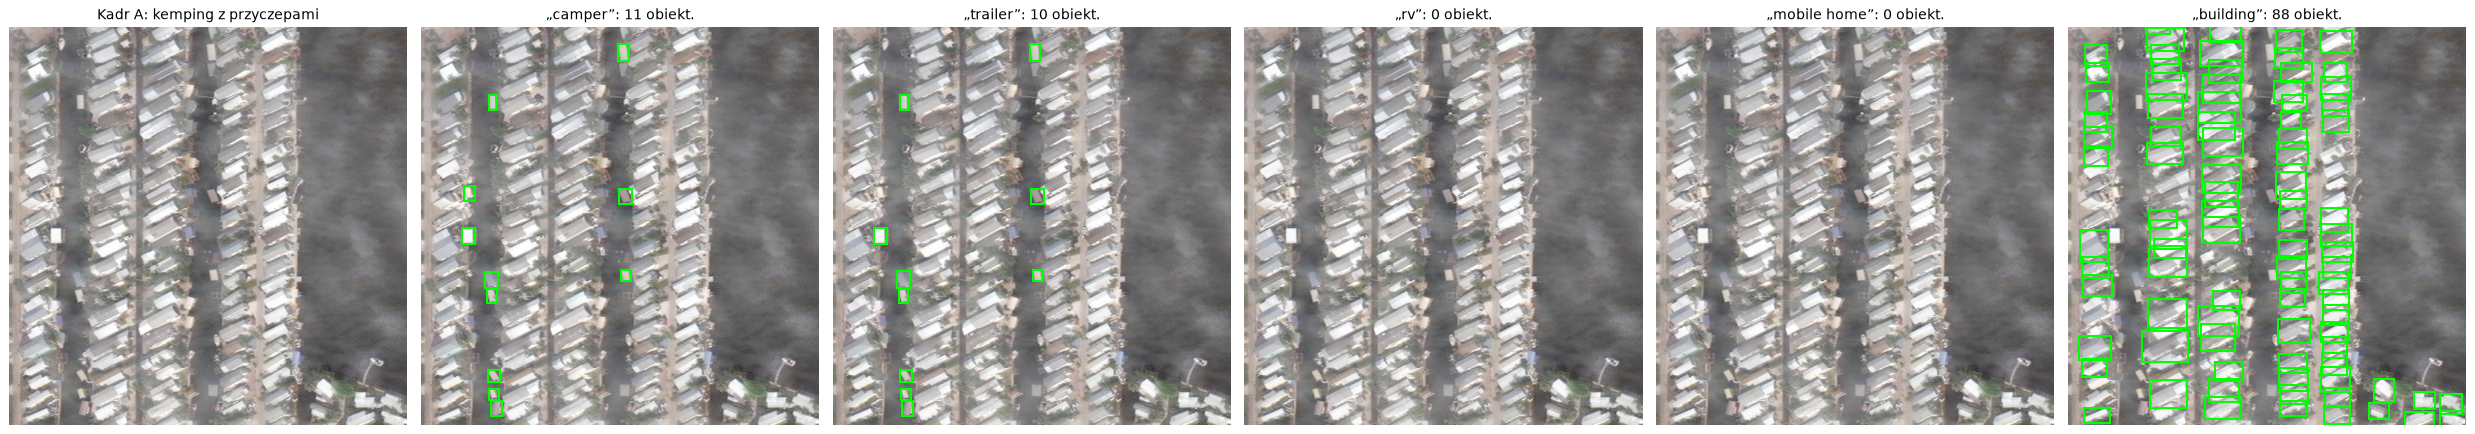

,obiektów,najwyższa pewność
camper,11.0,0.71
trailer,10.0,0.70
rv,0.0,0.00
mobile home,0.0,0.00
building,88.0,0.73


Dziennik Twoich prób (ostatnie 10):


,kadr,fraza,próg,obiektów,najwyższa pewność
0,A,camper,0.5,11,0.71
1,A,trailer,0.5,10,0.70
2,A,rv,0.5,0,0.00
3,A,mobile home,0.5,0,0.00
4,A,building,0.5,88,0.73


In [7]:
# TWOJA KOLEJ
# ==================== ZMIEŃ TU ====================
KADR = "A"
FRAZY = ["camper", "trailer", "rv", "mobile home", "building"]     # frazy po angielsku, oddzielone przecinkami
PROG = 0.5
# ===================================================

zadanie_frazy(KADR, FRAZY, PROG)

---

## Krok 2. Nazwa: łodzie na wodzie

### Zadanie 2. Która fraza najlepiej opisuje łodzie?

Kadr C to pole kotwiczenia na otwartej wodzie — dobre miejsce, żeby porównać kilka nazw łodzi naraz.

1. Uruchom **TWOJA KOLEJ** bez zmian.
2. Sprawdź te same frazy na kadrze D (osiedle kanałowe, łodzie przy prywatnych pomostach).


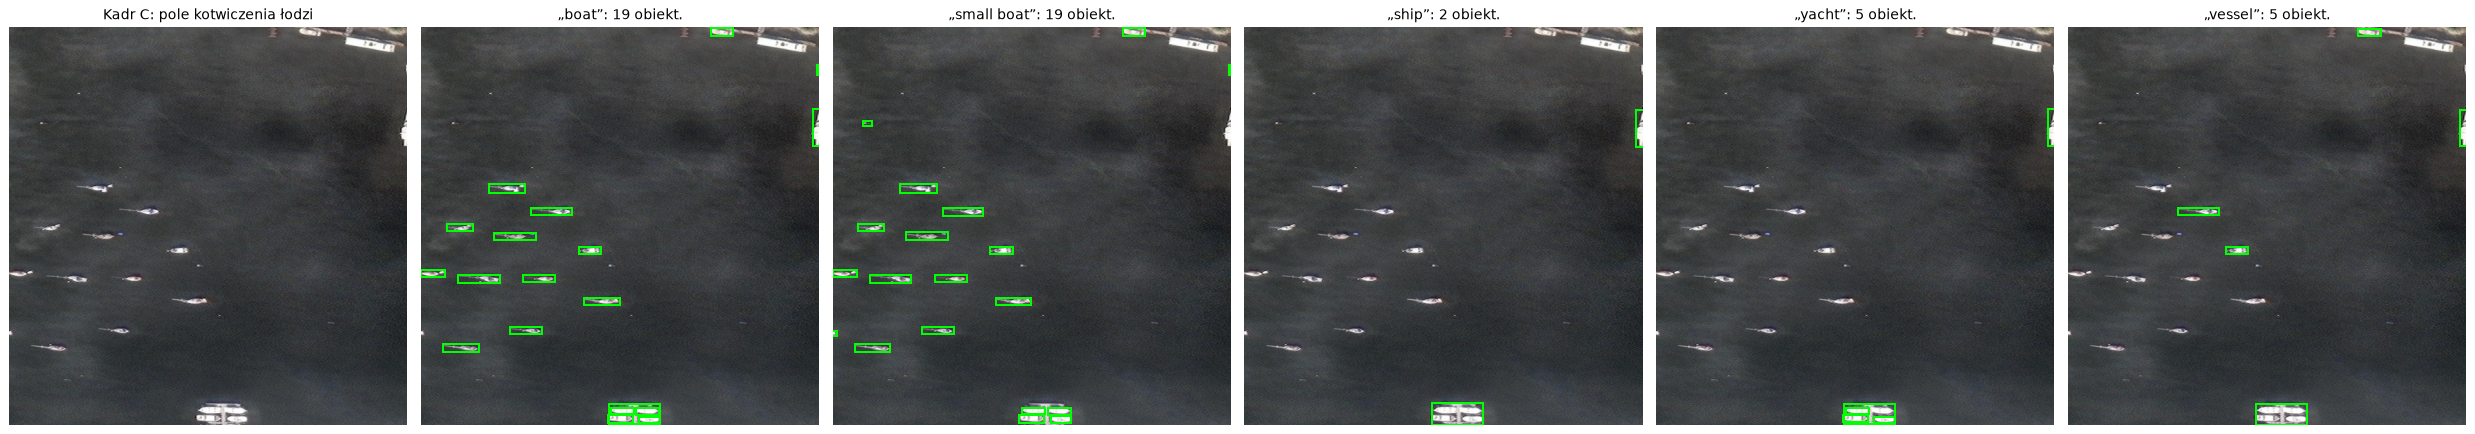

,obiektów,najwyższa pewność
boat,19.0,0.77
small boat,19.0,0.87
ship,2.0,0.90
yacht,5.0,0.70
vessel,5.0,0.78


Dziennik Twoich prób (ostatnie 10):


,kadr,fraza,próg,obiektów,najwyższa pewność
0,A,camper,0.5,11,0.71
1,A,trailer,0.5,10,0.70
2,A,rv,0.5,0,0.00
3,A,mobile home,0.5,0,0.00
4,A,building,0.5,88,0.73
5,C,boat,0.5,19,0.77
6,C,small boat,0.5,19,0.87
7,C,ship,0.5,2,0.90
8,C,yacht,0.5,5,0.70
9,C,vessel,0.5,5,0.78


In [8]:
# TWOJA KOLEJ
# ==================== ZMIEŃ TU ====================
KADR = "C"
FRAZY = ["boat", "small boat", "ship", "yacht", "vessel"]
PROG = 0.5
# ===================================================

zadanie_frazy(KADR, FRAZY, PROG)

---

## Krok 3. Próg pewności

### Zadanie 3. Ile obiektów zostaje przy różnych progach?

Tak jak w notebooku 06 (sekcja 3.3): każdy znaleziony obiekt ma **pewność**. Zbyt niski próg wpuszcza fałszywe alarmy,
zbyt wysoki gubi prawdziwe obiekty.

1. Uruchom **TWOJA KOLEJ** bez zmian (kadr A, `camper`, progi 0.2 / 0.4 / 0.6).
2. Uruchom **ROZWIĄZANIE** (kadr C, `boat`, progi 0.3 / 0.5 / 0.7) i porównaj kształt krzywej.


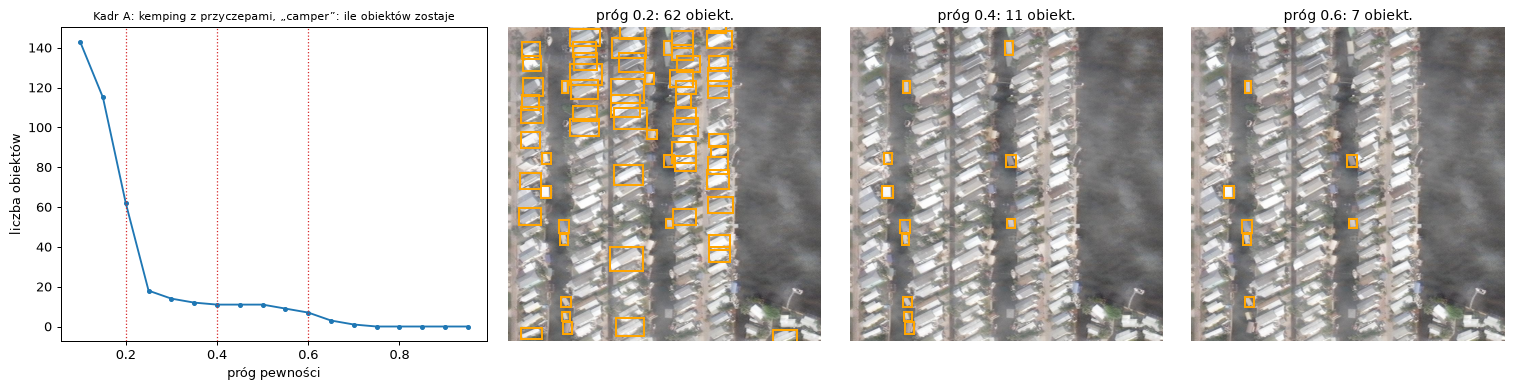

próg,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
obiektów,143,62,14,11,11,7,1,0,0


In [9]:
# TWOJA KOLEJ
# ==================== ZMIEŃ TU ====================
KADR = "A"
FRAZA = "camper"
PROGI = (0.2, 0.4, 0.6)      # trzy liczby z kropką, każda od 0.05 do 0.95
# ===================================================

zadanie_prog(KADR, FRAZA, PROGI)

---

## Krok 4. Całe zdjęcie i rozmiar kafla

### Zadanie 4. Cała ortofotomapa, trzy klasy naraz

Tak jak w notebooku 06 (sekcje 4–5): program tnie zdjęcie na kafelki, na każdym szuka Twoich fraz i zapisuje wszystkie
ramki do jednego pliku GPKG. Tu kafel działa inaczej niż w poziomie 4 (maski) — SAM 3 zawsze widzi kafel przeskalowany
do tej samej liczby pikseli (1008), więc **większy kafel w metrach = mniej dokładny obraz dla małych obiektów**, nie
tylko „więcej obetniętych krawędzi”.

1. Uruchom **TWOJA KOLEJ** bez zmian (`KAFEL_M = 200`; ok. 3–5 minut na GPU).
2. Uruchom **ROZWIĄZANIE** (`KAFEL_M = 350`, mniej kafli, szybciej) i porównaj liczby w dzienniku pod rysunkiem.


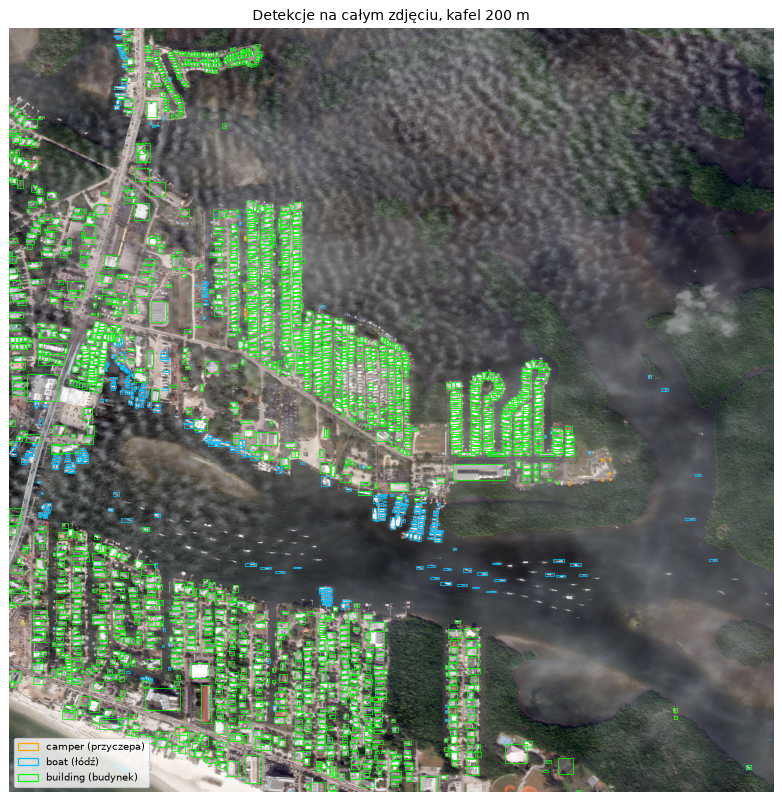

Kafli: 196, czas: 345 s (1.76 s/kafel).
Zapisano fort_myers_detekcje.gpkg (2154 obiektów) w wyniki/zadania_detekcja/


,klasa,obiektów,mediana pewności
fraza,,,
camper,przyczepa,28,0.55
boat,łódź,406,0.77
building,budynek,1720,0.77


Dziennik Twoich przebiegów:


,kafel [m],frazy,obiektów razem,czas [s]
0,200.0,"camper, boat, building",2154,345


In [10]:
# TWOJA KOLEJ
# ==================== ZMIEŃ TU ====================
KAFEL_M = 200                                                              # rozmiar kafla w metrach: 200, potem 350
FRAZY_I_KLASY = {"camper": "przyczepa", "boat": "łódź", "building": "budynek"}    # "fraza": "klasa"
PROG_PEWNOSCI = 0.5
# ===================================================

zadanie_cala(FRAZY_I_KLASY, KAFEL_M, PROG_PEWNOSCI)

---

## Krok 5. Ocena względem OSM

### Zadanie 5. Które klasy da się w ogóle sprawdzić?

`dane/fort_myers_osm.gpkg` ma warstwę `budynki` (1209 obiektów). Pojedyncze **łodzie i przyczepy kempingowe nie są w
OSM mapowane** — to nie jest luka w naszym pliku, sprawdziliśmy to przy pobieraniu danych (zapytanie do Overpass
zwróciło zero takich obiektów). To ważniejsza wersja lekcji z notebooka 06 („OSM to nie prawda terenowa”): czasem OSM
**w ogóle nie ma** żadnej referencji dla danej klasy, nie tylko niepełną.

1. Uruchom **TWOJA KOLEJ** (`zadanie_ocena_osm("building")`) — wymaga, żeby zadanie 4 zapisało plik z frazą `"building"`.
2. Uruchom **ROZWIĄZANIE** (`zadanie_ocena_osm("boat")`) i przeczytaj komunikat.


In [11]:
# TWOJA KOLEJ
zadanie_ocena_osm("building")

,wartość
OSM (referencja),1209.000
OSM dopasowanych,712.000
przybliżona czułość,0.589
detekcji SAM 3,1720.000
detekcji bez OSM,897.000


Przybliżona czułość: 58.9% (712 z 1209 obiektów OSM „budynki” ma pasującą detekcję).
Detekcji bez odpowiednika w OSM: 897 z 1720 — to NIE są automatycznie fałszywe alarmy (OSM może po prostu nie mapować tego miejsca).


{'OSM (referencja)': 1209,
 'OSM dopasowanych': 712,
 'przybliżona czułość': np.float64(0.589),
 'detekcji SAM 3': 1720,
 'detekcji bez OSM': 897}

---

### Ściągawka: co zmienić, gdy widzisz taki wynik

| Co widzisz | Co to znaczy | Co zrobić |
|---|---|---|
| Fraza (np. `rv`) daje 0 obiektów | Model nie zna tej nazwy w tym kontekście | Wypróbuj 2–3 inne nazwy (kroki 1–2): prostsze rzeczowniki działają lepiej niż żargon |
| Inna fraza (np. `building`) łapie też Twoje obiekty | Fraza determinuje zbiór silniej niż wygląd | Zawsze sprawdzaj na rysunku, nie tylko liczbę; wybierz frazę, która nie „podkrada” obiektów innym klasom |
| Liczba obiektów gwałtownie rośnie przy niskim progu | Próg za niski, wpuszcza fałszywe alarmy | Podnieś próg do miejsca, gdzie krzywa się wypłaszcza (krok 3) |
| Prawdziwe obiekty znikają przy wysokim progu | Próg za wysoki | Obniżaj go stopniowo, oglądając rysunek |
| Mały obiekt znika przy dużym kaflu | Kafel w metrach = efektywna rozdzielczość obrazu dla modelu | Zmniejsz `KAFEL_M` (krok 4) |
| Duży obiekt (np. droga, długi pomost) znika na kaflach | Ramka dotykała krawędzi kafla — odrzucona | Zwiększ `KAFEL_M` |
| Wiele detekcji bez odpowiednika w OSM | OSM może po prostu nie mapować tego miejsca | Obejrzyj kilka z bliska w QGIS, zanim uznasz je za błędy |
| Ocena OSM odmawia policzenia frazy | Ta klasa w ogóle nie ma referencji w OSM | Sprawdź, czy Twoja fraza jest w `POJECIE_NA_WARSTWE_OSM` |

### Recepta dla Fort Myers Beach (propozycja prowadzącego)

| Co chcę zliczyć | Klasa | Fraza, która zadziałała | Próg | Kafel [m] | Na co uważać |
|---|---|---|---|---|---|
| przyczepy kempingowe | przyczepa | `camper` (`trailer` też działa; `rv`, `mobile home` nie) | 0.4–0.5 | 200 | `building` łapie też przyczepy — sprawdzaj rysunek |
| łodzie | łódź | `boat` / `small boat` (`ship` tylko duże jednostki) | 0.4–0.5 | 200 (łodzie zniosłyby i 350) | przy niskim progu szybko przybywają fałszywe alarmy na falach |
| budynki | budynek | `building` | 0.5 | 200 | jedyna klasa z sensownym odniesieniem w OSM (czułość ~59 %) |

## Dla chętnych

- **Własne zdjęcie.** Wpisz ścieżkę do własnego GeoTIFF-a (8-bitowe RGB, układ metryczny) w komórce poniżej: dostaniesz
  ramki dla swoich fraz na całym zdjęciu. Najpierw sprawdź frazy na małym kadrze (jak w krokach 1–3), bo to, co
  zadziałało w Fort Myers, nie musi zadziałać u Ciebie.
- **Czwarta fraza.** Dopisz `"car"` do `FRAZY_I_KLASY` w zadaniu 4 (potrzebujesz nowej nazwy klasy w `KLASY_DO_WYBORU`,
  np. `"pojazd"` — dopisz ją w komórce GOTOWE z funkcjami, jeśli chcesz to zrobić na poważnie). Ile aut jest na
  parkingach przy plaży (kadr E)?
- **Etykiety do treningu U-Net.** Ten notebook daje ramki, nie maski pikselowe — do douczania modelu z poziomu 3
  potrzebujesz masek, tak jak w notebooku 04 (`post_process_instance_segmentation`, nie `post_process_object_detection`).

In [ ]:
# TWOJA KOLEJ (dla chętnych)
# ==================== ZMIEŃ TU ====================
MOJE_ZDJECIE = None                                                # np. "dane/moje_zdjecie.tif"; None = pomiń tę komórkę
MOJE_FRAZY_I_KLASY = {"boat": "łódź", "building": "budynek"}       # frazy, które sprawdziłeś w krokach 1-3 dla SWOJEGO zdjęcia
MOJ_KAFEL_M = 200
# ===================================================

if MOJE_ZDJECIE is None:
    print("Pominięto: nie wskazałeś własnego zdjęcia.")
else:
    SCIEZKA_ZDJECIA = Path(MOJE_ZDJECIE)
    try:
        rgb, waznie, profil, gsd = wczytaj_zdjecie(SCIEZKA_ZDJECIA)
    except (ValueError, rasterio.errors.RasterioIOError) as blad:
        print(f"⚠️  Nie mogę wczytać zdjęcia: {blad}")
    else:
        print(f"Zdjęcie: {rgb.shape[1]} × {rgb.shape[0]} px, piksel {gsd * 100:.1f} cm. Kadry A-E z Fort Myers już nie "
              "pasują: żeby do nich wrócić, uruchom notebook od nowa.")
        zadanie_cala(MOJE_FRAZY_I_KLASY, MOJ_KAFEL_M)